In [9]:
# 1. Importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid')

In [10]:
# Ajuste o caminho caso o notebook esteja em outra pasta
url = 'https://docs.google.com/spreadsheets/d/1Ou9RFvSBZHRtVLkEi45qsjfY8aB4dT1bYFz-cdeuwFw/export?format=xlsx'

df = pd.read_excel(url)
print(df.shape)
df.head()

(26, 12)


,Coluna 1,Coluna 2,Coluna 3,Coluna 4,Coluna 5,Coluna 6,Coluna 7,Coluna 8,Coluna 9,Coluna 10,Coluna 11,Coluna 12
0,2026-08-29 18:07:03.613,Projeto Arthur,Dados,Italo Dias,TCAR,3000,0.00,0.00,0,2026-08-29,2026-09-29,Iniciado
1,2026-08-30 15:31:26.000,Projeto Horizonte,Dados,Larissa Costa,Nexus Cloud,25000,4334.60,6684.61,1,2024-02-01,2024-06-03,Concluído
2,2026-08-31 15:31:26.000,Projeto Meridiano,Mobile,Rafael Souza,NimbusSoft,20000,1143.66,5287.52,0,2024-02-23,2024-05-24,Concluído
3,2026-09-01 15:31:26.000,Projeto Kite,Desktop,Pedro de Pádua,Jagger CO,5000,18.09,547.03,1,2024-03-31,2024-05-19,Concluído
4,2026-09-02 15:31:26.000,Projeto Zênite,Sites,Marcos Vinícius,Delta Consult,18000,2939.50,657.77,1,2024-05-03,2024-09-07,Concluído


In [11]:
mapa_colunas = {
    'Coluna 1': 'data_registro',                      # timestamp do formulário
    'Coluna 2': 'nome_projeto',
    'Coluna 3': 'area',                                # dados / mobile / desktop / sites
    'Coluna 4': 'responsavel',
    'Coluna 5': 'cliente',
    'Coluna 6': 'valor_total_projeto',                 # valor contratado do projeto
    'Coluna 7': 'valor_faturamento_colaborativo',      # faturamento sem o custo
    'Coluna 8': 'valor_custo',                         # custo do projeto para a ej
    'Coluna 9': 'projeto_de_impacto',                  # 0/1 -> binário para previsão futura
    'Coluna 10': 'data_inicio',
    'Coluna 11': 'data_fim',
    'Coluna 12': 'status',                             # concluído / em andamento / iniciado
}

df = df.rename(columns=mapa_colunas)
df.head()


,data_registro,nome_projeto,area,responsavel,cliente,valor_total_projeto,valor_faturamento_colaborativo,valor_custo,projeto_de_impacto,data_inicio,data_fim,status
0,2026-08-29 18:07:03.613,Projeto Arthur,Dados,Italo Dias,TCAR,3000,0.00,0.00,0,2026-08-29,2026-09-29,Iniciado
1,2026-08-30 15:31:26.000,Projeto Horizonte,Dados,Larissa Costa,Nexus Cloud,25000,4334.60,6684.61,1,2024-02-01,2024-06-03,Concluído
2,2026-08-31 15:31:26.000,Projeto Meridiano,Mobile,Rafael Souza,NimbusSoft,20000,1143.66,5287.52,0,2024-02-23,2024-05-24,Concluído
3,2026-09-01 15:31:26.000,Projeto Kite,Desktop,Pedro de Pádua,Jagger CO,5000,18.09,547.03,1,2024-03-31,2024-05-19,Concluído
4,2026-09-02 15:31:26.000,Projeto Zênite,Sites,Marcos Vinícius,Delta Consult,18000,2939.50,657.77,1,2024-05-03,2024-09-07,Concluído


In [12]:
df['projeto_de_impacto'] = df['projeto_de_impacto'].astype(bool)
df['status'] = df['status'].str.strip()
df['area'] = df['area'].str.strip()

print('Linhas duplicadas:', df.duplicated().sum())
print()
print('Valores nulos por coluna:')
print(df.isna().sum())
print()
print('Categorias de área:', df['area'].unique())
print('Categorias de status:', df['status'].unique())

Linhas duplicadas: 0

Valores nulos por coluna:
data_registro                     0
nome_projeto                      0
area                              0
responsavel                       0
cliente                           0
valor_total_projeto               0
valor_faturamento_colaborativo    0
valor_custo                       0
projeto_de_impacto                0
data_inicio                       0
data_fim                          0
status                            0
dtype: int64

Categorias de área: <StringArray>
['Dados', 'Mobile', 'Desktop', 'Sites']
Length: 4, dtype: str
Categorias de status: <StringArray>
['Iniciado', 'Concluído', 'Em andamento']
Length: 3, dtype: str


In [13]:
df['ano_inicio'] = df['data_inicio'].dt.year
df['mes_inicio'] = df['data_inicio'].dt.month
df['ano_mes_inicio'] = df['data_inicio'].dt.to_period('M').astype(str)
df['duracao_dias'] = (df['data_fim'] - df['data_inicio']).dt.days

df[['nome_projeto', 'data_inicio', 'data_fim', 'duracao_dias', 'ano_mes_inicio']].head()


,nome_projeto,data_inicio,data_fim,duracao_dias,ano_mes_inicio
0,Projeto Arthur,2026-08-29,2026-09-29,31,2026-08
1,Projeto Horizonte,2024-02-01,2024-06-03,123,2024-02
2,Projeto Meridiano,2024-02-23,2024-05-24,91,2024-02
3,Projeto Kite,2024-03-31,2024-05-19,49,2024-03
4,Projeto Zênite,2024-05-03,2024-09-07,127,2024-05


/tmp/ipykernel_1273/2057925987.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(faturamento_mensal['ano_mes_inicio'], rotation=45, ha='right')


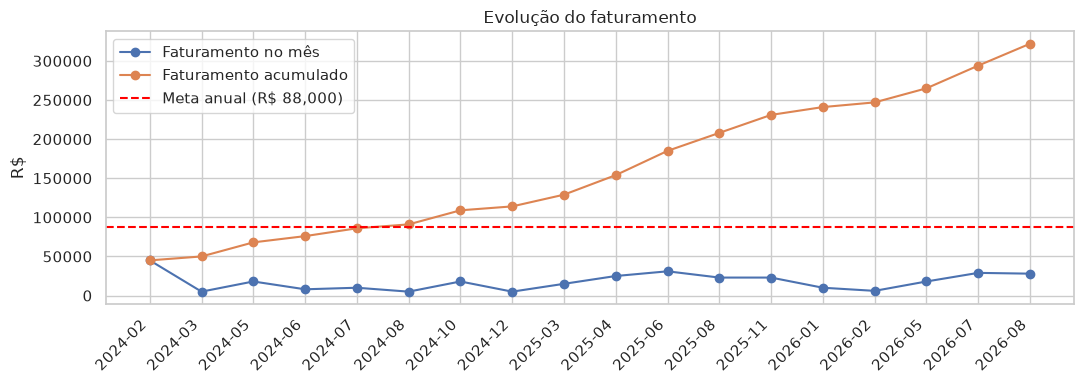

,ano_mes_inicio,valor_total_projeto,faturamento_acumulado
0,2024-02,45000,45000
1,2024-03,5000,50000
2,2024-05,18000,68000
3,2024-06,8000,76000
4,2024-07,10000,86000
5,2024-08,5000,91000
6,2024-10,18000,109000
7,2024-12,5000,114000
8,2025-03,15000,129000
9,2025-04,25000,154000


In [14]:
META_ANUAL = 88000

faturamento_mensal = (
    df.groupby('ano_mes_inicio', as_index=False)['valor_total_projeto']
      .sum()
      .sort_values('ano_mes_inicio')
      .reset_index(drop=True)
)
faturamento_mensal['faturamento_acumulado'] = faturamento_mensal['valor_total_projeto'].cumsum()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(faturamento_mensal['ano_mes_inicio'], faturamento_mensal['valor_total_projeto'],
        marker='o', label='Faturamento no mês')
ax.plot(faturamento_mensal['ano_mes_inicio'], faturamento_mensal['faturamento_acumulado'],
        marker='o', label='Faturamento acumulado')
ax.axhline(META_ANUAL, color='red', linestyle='--', label=f'Meta anual (R$ {META_ANUAL:,.0f})')
ax.set_xticklabels(faturamento_mensal['ano_mes_inicio'], rotation=45, ha='right')
ax.set_ylabel('R$')
ax.set_title('Evolução do faturamento')
ax.legend()
plt.tight_layout()
plt.show()

faturamento_mensal


In [15]:
cluster_base = df.groupby('ano_mes_inicio').agg(
    faturamento_total=('valor_total_projeto', 'sum'),
    faturamento_colaborativo=('valor_faturamento_colaborativo', 'sum'),
    qtd_projetos=('nome_projeto', 'count'),
    qtd_projetos_impacto=('projeto_de_impacto', 'sum'),
    qtd_projetos_concluidos=('status', lambda s: (s == 'Concluído').sum()),
).reset_index()

cluster_base['pct_projetos_impacto'] = cluster_base['qtd_projetos_impacto'] / cluster_base['qtd_projetos']
cluster_base


,ano_mes_inicio,faturamento_total,faturamento_colaborativo,qtd_projetos,qtd_projetos_impacto,qtd_projetos_concluidos,pct_projetos_impacto
0,2024-02,45000,5478.26,2,1,2,0.5
1,2024-03,5000,18.09,1,1,1,1.0
2,2024-05,18000,2939.50,1,1,1,1.0
3,2024-06,8000,276.85,1,1,1,1.0
4,2024-07,10000,254.76,1,0,1,0.0
5,2024-08,5000,1434.77,1,1,1,1.0
6,2024-10,18000,0.00,1,1,1,1.0
7,2024-12,5000,9605.16,1,0,1,0.0
8,2025-03,15000,0.00,1,0,1,0.0
9,2025-04,25000,1480.98,2,1,2,0.5


In [ ]:
colunas_numericas = [
    'faturamento_total',
    'faturamento_colaborativo',
    'qtd_projetos',
    'qtd_projetos_impacto',
    'pct_projetos_impacto',
]

scaler = StandardScaler()
cluster_base_scaled = cluster_base.copy()
cluster_base_scaled[colunas_numericas] = scaler.fit_transform(cluster_base[colunas_numericas])
cluster_base_scaled
